In [6]:
# Data Loading & Exploration
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)


# Display Setup
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

In [7]:
# Dataset loading
try:
    # File path - if the file is in the project folder
    file_path = r"../../datasets/bank-additional/bank-additional-full.csv"
    df = pd.read_csv(file_path, sep=';')
    print("Dataset successfully loaded.")

except FileNotFoundError:
    url = "https://raw.githubusercontent.com/mkhazaeidev/DataMiningTutorial/main/datasets/bank-additional/bank-additional-full.csv"
    df = pd.read_csv(url, sep=';')
    print("Dataset successfully downloaded.")

    # print("Error: File not found. Please download from the link below:")
    # print("https://archive.ics.uci.edu/ml/machine-learning-databases/00222/bank-additional.zip")

Dataset successfully downloaded.


In [8]:
# Initial Exploration
print("First 5 rows of data:")
print(df.head())

print("\nLast 5 rows of data:")
print(df.tail())

# General information about the dataframe
print("\nShape information:")
print(
    f"Data dimensions: {df.shape} (number of rows: {df.shape[0]}, number of columns: {df.shape[1]})"
)
print("\nStructural Information:")
df.info()

print("\nNames of all columns:")
print(df.columns.tolist())
print(f"\nNumber of columns: {len(df.columns)}")

# Descriptive statistics
print("\nDescriptive statistics (numeric columns):")
print(df.describe())

print("\nDescriptive statistics (non-numeric columns):")
print(df.describe(include=['object']))

First 5 rows of data:
   age        job  marital    education  default housing loan    contact month day_of_week  duration  campaign  pdays  previous     poutcome  emp.var.rate  cons.price.idx  cons.conf.idx  euribor3m  nr.employed   y
0   56  housemaid  married     basic.4y       no      no   no  telephone   may         mon       261         1    999         0  nonexistent           1.1          93.994          -36.4      4.857       5191.0  no
1   57   services  married  high.school  unknown      no   no  telephone   may         mon       149         1    999         0  nonexistent           1.1          93.994          -36.4      4.857       5191.0  no
2   37   services  married  high.school       no     yes   no  telephone   may         mon       226         1    999         0  nonexistent           1.1          93.994          -36.4      4.857       5191.0  no
3   40     admin.  married     basic.6y       no      no   no  telephone   may         mon       151         1    999     

In [9]:
print("Checking for Missing Values")

# Check for null values
missing_data = df.isnull().sum()
missing_percent = (df.isnull().sum() / len(df)) * 100

print("Missing values ​​in each column:")
missing_info = pd.DataFrame({
    'column': df.columns,
    'missing_value': missing_data,
    'missing_percentage': missing_percent
})
print(missing_info[missing_info['missing_value'] > 0])
if missing_data.sum() == 0:
    print("There are no missing values ​in the data!")
else:
    print(f"Total missing values: {missing_data.sum()}")

Checking for Missing Values
Missing values ​​in each column:
Empty DataFrame
Columns: [column, missing_value, missing_percentage]
Index: []
There are no missing values ​in the data!


In [10]:
# Check for duplicate data"

duplicates = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicates}")

if duplicates > 0:
    print(f"Percentage of duplicate data: {(duplicates/len(df))*100:.2f}%")
else:
    print("There are no duplicates")

Number of duplicate rows: 12
Percentage of duplicate data: 0.03%


Distribution of the target variable 'y':
Number:
y
no     36548
yes     4640
Name: count, dtype: int64

Percentage:
y
no     88.734583
yes    11.265417
Name: proportion, dtype: float64


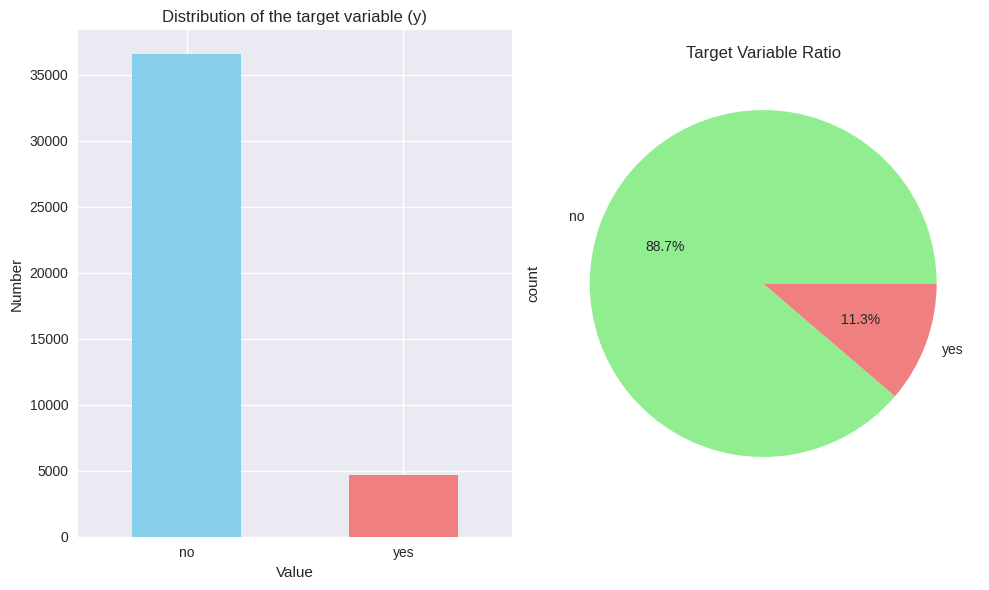


Data Balance Analysis:
Majority Class to Minority Class Ratio:     7.88 to 1
Solution: You can use techniques such as         class weighting or sampling were used


In [11]:
# Analysis of the target variable (y)

# Check the distribution of the target variable
target_column = 'y'  # This is our target column

print(f"Distribution of the target variable '{target_column}':")
target_distribution = df[target_column].value_counts()
target_percentage = df[target_column].value_counts(normalize=True) * 100

print("Number:")
print(target_distribution)
print("\nPercentage:")
print(target_percentage)

# Distribution of the target variable
plt.figure(figsize=(10, 6))

plt.subplot(1, 2, 1)
df[target_column].value_counts().plot(
    kind='bar',
    color=['skyblue', 'lightcoral']
)
plt.title('Distribution of the target variable (y)')
plt.xlabel('Value')
plt.ylabel('Number')
plt.xticks(rotation=0)

plt.subplot(1, 2, 2)
df[target_column].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    colors=['lightgreen', 'lightcoral']
)
plt.title('Target Variable Ratio')

plt.tight_layout()
plt.show()

# Data Balance Importance Analysis
print(f"\nData Balance Analysis:")
print(
    f"Majority Class to Minority Class Ratio: \
    {target_distribution.max()/target_distribution.min():.2f} to 1"
)

if target_percentage.max() / target_percentage.min() > 4:
    print("Warning: Data is unbalanced! This may affect model performance.")
    print(
        "Solution: You can use techniques such as \
        class weighting or sampling were used"
    )
else:
    print("The data is relatively balanced")

In [ ]:
# Numerical Variables Analysis

# Identify numeric columns
numeric_columns = df.select_dtypes(include=[np.number]).columns
print(f"Numeric columns: {list(numeric_columns)}")

if len(numeric_columns) > 0:
    # Calculate network dimensions dynamically
    number_cols = len(numeric_columns)
    number_rows = (number_cols + 2) // 3

    # Histogram for all numeric variables
    plt.figure(figsize=(15, 5 * number_rows))

    for index, col in enumerate(numeric_columns):
        plt.subplot(number_rows, 3, index + 1)
        df[col].hist(bins=30, alpha=0.7, color='skyblue')
        plt.title(f'Distribution {col}')
        plt.xlabel(col)
        plt.ylabel('Number')

    plt.tight_layout()
    plt.show()

    # Boxplot for outlier detection
    plt.figure(figsize=(15, 5 * number_rows))
    for i, col in enumerate(numeric_columns):
        plt.subplot(number_cols, 3, i+1)
        df.boxplot(column=col)
        plt.title(f'Boxplot {col}')

    plt.tight_layout()
    plt.show()
else:
    print("No numeric columns found!")